## Set up your Python environment

EzTaoX requires Python >=3.9,<3.13. 

To create a virtual environment with conda, please follow the next steps:
```bash
conda create -n eztaox python=3.12
conda activate eztaox
pip install eztaox lsdb jupyter arviz netCDF4 matplotlib
python -m ipykernel install --user --name eztaox --display-name "EzTaoX (Python 3.12)"
```

You should now be able to select the EzTaoX kernel from your Jupyter notebook.

In [1]:
import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import jax.numpy as jnp

from dask.distributed import Client
from nested_pandas import NestedDtype
from nested_pandas.utils import count_nested


### Load DP1 DIA objects

In [2]:
dia_object_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dia_object_collection",
    columns=["ra", "dec", "diaObjectId", "nDiaSources", "diaObjectForcedSource"],
    filters=[["nDiaSources", ">", 10]],
)
print(f"Number of DIA objects in DP1: {len(dia_object_cat):,}")

Number of DIA objects in DP1: 1,089,818


### Remove objects with flags

In [3]:
# Remove all objects which have at least one of the flags set
flag_subcols = [
    c for c in dia_object_cat["diaObjectForcedSource"].columns if "flag" in c.lower()
]
dia_object_cat = dia_object_cat.query(
    " and ".join([f"diaObjectForcedSource.{c} != 1" for c in flag_subcols])
)

### Remove NA values

- Remove all forced sources with NA mjds/mags.
- Remove all objects with no forced sources.

In [4]:
def remove_na_sources(df):
    subcols = [
        f"diaObjectForcedSource.{subcol}"
        for subcol in ["midpointMjdTai", "psfMag", "psfMagErr"]
    ]
    return df.dropna(subset=subcols).dropna(subset="diaObjectForcedSource")


dia_object_cat = dia_object_cat.map_partitions(remove_na_sources)
dia_object_cat

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


### Clean up light curves

Remove outliers, bin by day and combine magnitudes.

In [5]:
def _remove_outliers(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    outlier_snr: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Remove data points beyond outlier_snr standard deviations from the mean."""
    if len(time_band) <= 1 or np.nanstd(mag_band) == 0:
        return time_band, mag_band, magerr_band

    sigma = np.abs(mag_band - np.nanmean(mag_band)) / np.nanstd(mag_band)
    mask = sigma < outlier_snr
    return time_band[mask], mag_band[mask], magerr_band[mask]


def _bin_band(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    band_label: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Bin observations by epoch (rounded to nearest day) and combine magnitudes."""
    rounded_times = np.round(time_band)
    unique_epochs = np.unique(rounded_times)

    binned_times, binned_mags, binned_magerrs = [], [], []
    for epoch in unique_epochs:
        epoch_mask = rounded_times == epoch
        tmp_mag, tmp_err = _combine_mag(mag_band[epoch_mask], magerr_band[epoch_mask])
        binned_times.append(epoch)
        binned_mags.append(tmp_mag)
        binned_magerrs.append(tmp_err)

    binned_bands = np.full(len(unique_epochs), band_label)
    return (
        np.array(binned_times),
        binned_bands,
        np.array(binned_mags),
        np.array(binned_magerrs),
    )


def _combine_mag(mag, mag_err):
    ## add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617
    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err) ** 2 + np.nanstd(mag) ** 2)
    return mag_w, mag_w_err


def clean_lightcurves(
    time: np.ndarray,
    band: np.ndarray,
    mag: np.ndarray,
    magerr: np.ndarray,
    outlier_snr: float = 10.0,
    binning: bool = True,
) -> dict[str, np.ndarray]:
    """
    Clean light curves by removing outliers and optionally binning by epoch.

    Args:
        time:        Timestamps (MJD).
        band:        Band labels.
        mag:         Magnitudes.
        magerr:      Magnitude errors.
        outlier_snr: Sigma threshold for outlier rejection.
        binning:     If True, combine observations within the same epoch.

    Returns:
        Dictionary with cleaned times, bands, magnitudes, and magnitude errors,
        sorted by time.
    """
    times, bands, mags, magerrs = [], [], [], []

    for b in np.unique(band):
        band_mask = band == b
        time_band, mag_band, magerr_band = (
            time[band_mask],
            mag[band_mask],
            magerr[band_mask],
        )

        time_band, mag_band, magerr_band = _remove_outliers(
            time_band, mag_band, magerr_band, outlier_snr
        )

        if binning:
            t, b_arr, m, me = _bin_band(time_band, mag_band, magerr_band, b)
        else:
            t, b_arr, m, me = (
                time_band,
                np.full(len(time_band), b),
                mag_band,
                magerr_band,
            )

        times.append(t)
        bands.append(b_arr)
        mags.append(m)
        magerrs.append(me)

    times, bands, mags, magerrs = (
        np.concatenate(times),
        np.concatenate(bands),
        np.concatenate(mags),
        np.concatenate(magerrs),
    )

    ind_sort = np.argsort(times)
    return {
        "cleanLC.Mjd": times[ind_sort],
        "cleanLC.Band": bands[ind_sort],
        "cleanLC.Mag": mags[ind_sort],
        "cleanLC.MagErr": magerrs[ind_sort],
    }

Process all light curves in parallel:

In [8]:
result_binned = dia_object_cat.map_rows(
    clean_lightcurves,
    columns=[
        "diaObjectForcedSource.midpointMjdTai",
        "diaObjectForcedSource.band",
        "diaObjectForcedSource.psfMag",
        "diaObjectForcedSource.psfMagErr",
    ],
    meta={
        "cleanLC": NestedDtype(
            {
                "Mjd": pa.float64(),
                "Band": pa.string(),
                "Mag": pa.float64(),
                "MagErr": pa.float64(),
            }
        )
    },
    row_container="args",
    append_columns=True,
    binning=True,
)

In [9]:
with Client(n_workers=4):
    df_clean_binned = result_binned.compute()
df_clean_binned

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
9199596288106482     38.220207    6.19294  648370049710555138           11   
9200141817748620     38.347676   6.225814  648370668185845779           12   
...                        ...        ...                 ...          ...   
2531148760694283112  40.010525 -34.057562  605447795821772807           16   
2531148928056845706  39.930333   -34.0739  605447864541249557           12   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
9199596288106482     [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620     [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                                ...   
2531148760694283112  [{parentObjectId: 0, coord_ra: 40.010525, coor...   
2531148928056845706  [{parentObjectId: 0, coord_ra: 39.930333, coor...   

                                                               cleanLC  
_healpix_29                                                             
9199596288106482     [{Mjd: 60638.0, Band: 'i', Mag: 15.768791, Mag...  
9200141817748620     [{Mjd: 60638.0, Band: 'i', Mag: 16.404484, Mag...  
...                                                                ...  
2531148760694283112  [{Mjd: 60639.0, Band: 'i', Mag: 17.445753, Mag...  
2531148928056845706  [{Mjd: 60639.0, Band: 'i', Mag: 18.086699, Mag...  

[47347 rows x 6 columns]

In [13]:
df_clean_binned = count_nested(df_clean_binned, "cleanLC")
df_clean_binned

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
9199596288106482     38.220207    6.19294  648370049710555138           11   
9200141817748620     38.347676   6.225814  648370668185845779           12   
...                        ...        ...                 ...          ...   
2531148760694283112  40.010525 -34.057562  605447795821772807           16   
2531148928056845706  39.930333   -34.0739  605447864541249557           12   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
9199596288106482     [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620     [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                                ...   
2531148760694283112  [{parentObjectId: 0, coord_ra: 40.010525, coor...   
2531148928056845706  [{parentObjectId: 0, coord_ra: 39.930333, coor...   

                                                               cleanLC  \
_healpix_29                                                              
9199596288106482     [{Mjd: 60638.0, Band: 'i', Mag: 15.768791, Mag...   
9200141817748620     [{Mjd: 60638.0, Band: 'i', Mag: 16.404484, Mag...   
...                                                                ...   
2531148760694283112  [{Mjd: 60639.0, Band: 'i', Mag: 17.445753, Mag...   
2531148928056845706  [{Mjd: 60639.0, Band: 'i', Mag: 18.086699, Mag...   

                     n_cleanLC  
_healpix_29                     
9199596288106482             8  
9200141817748620             6  
...                        ...  
2531148760694283112          5  
2531148928056845706          5  

[47347 rows x 7 columns]

In [10]:
result_unbinned = dia_object_cat.map_rows(
    clean_lightcurves,
    columns=[
        "diaObjectForcedSource.midpointMjdTai",
        "diaObjectForcedSource.band",
        "diaObjectForcedSource.psfMag",
        "diaObjectForcedSource.psfMagErr",
    ],
    meta={
        "cleanLC": NestedDtype(
            {
                "Mjd": pa.float64(),
                "Band": pa.string(),
                "Mag": pa.float64(),
                "MagErr": pa.float64(),
            }
        )
    },
    row_container="args",
    append_columns=True,
    binning=False,
)

In [11]:
with Client(n_workers=4):
    df_clean_unbinned = result_unbinned.compute()
df_clean_unbinned

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
9199596288106482     38.220207    6.19294  648370049710555138           11   
9200141817748620     38.347676   6.225814  648370668185845779           12   
...                        ...        ...                 ...          ...   
2531148760694283112  40.010525 -34.057562  605447795821772807           16   
2531148928056845706  39.930333   -34.0739  605447864541249557           12   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
9199596288106482     [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620     [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                                ...   
2531148760694283112  [{parentObjectId: 0, coord_ra: 40.010525, coor...   
2531148928056845706  [{parentObjectId: 0, coord_ra: 39.930333, coor...   

                                                               cleanLC  
_healpix_29                                                             
9199596288106482     [{Mjd: 60638.125741, Band: 'r', Mag: 15.973674...  
9200141817748620     [{Mjd: 60638.125741, Band: 'r', Mag: 16.568659...  
...                                                                ...  
2531148760694283112  [{Mjd: 60639.244622, Band: 'r', Mag: 17.984379...  
2531148928056845706  [{Mjd: 60639.244622, Band: 'r', Mag: 18.537888...  

[47347 rows x 6 columns]

In [14]:
df_clean_unbinned = count_nested(df_clean_unbinned, "cleanLC")
df_clean_unbinned

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
9199596288106482     38.220207    6.19294  648370049710555138           11   
9200141817748620     38.347676   6.225814  648370668185845779           12   
...                        ...        ...                 ...          ...   
2531148760694283112  40.010525 -34.057562  605447795821772807           16   
2531148928056845706  39.930333   -34.0739  605447864541249557           12   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
9199596288106482     [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620     [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                                ...   
2531148760694283112  [{parentObjectId: 0, coord_ra: 40.010525, coor...   
2531148928056845706  [{parentObjectId: 0, coord_ra: 39.930333, coor...   

                                                               cleanLC  \
_healpix_29                                                              
9199596288106482     [{Mjd: 60638.125741, Band: 'r', Mag: 15.973674...   
9200141817748620     [{Mjd: 60638.125741, Band: 'r', Mag: 16.568659...   
...                                                                ...   
2531148760694283112  [{Mjd: 60639.244622, Band: 'r', Mag: 17.984379...   
2531148928056845706  [{Mjd: 60639.244622, Band: 'r', Mag: 18.537888...   

                     n_cleanLC  
_healpix_29                     
9199596288106482            12  
9200141817748620            12  
...                        ...  
2531148760694283112         17  
2531148928056845706         21  

[47347 rows x 7 columns]

Text(0, 0.5, 'Counts')

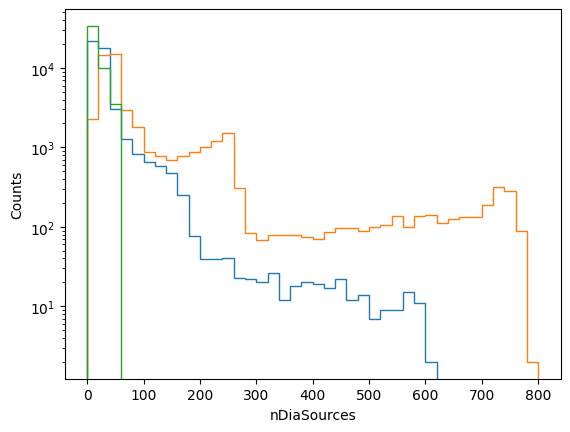

In [17]:
plt.hist(df_clean_binned["nDiaSources"], bins=40,range=(0,800),histtype='step',label='nDiaSources')
#plt.hist(df_clean["n_cleanLC"], bins=40,range=(0,800),histtype='step')
plt.hist(df_clean_unbinned["n_cleanLC"], bins=40,range=(0,800),histtype='step',label='unbinned')
plt.hist(df_clean_binned["n_cleanLC"], bins=40,range=(0,800),histtype='step',label='binned')
plt.yscale("log")
plt.xlabel("nDiaSources")
plt.ylabel("Counts")

### EzTaoX fitting

In [18]:
def format_lightcurves(time_arr, band_arr, mag_arr, magerr_arr):
    """Prepare light curves for fitting"""
    
    band_unique = np.unique(band_arr)
    times, mags, magerrs = {},{},{}
    for i, b in enumerate(band_unique):
        ind = np.where(band_arr==b)[0]
        times[b] = np.asarray(time_arr[ind])
        mags[b] = np.asarray(mag_arr[ind])
        magerrs[b] = np.asarray(magerr_arr[ind])
    bands = times.keys()
    
    inds = jnp.argsort(jnp.concatenate([times[b] for b in bands]))
    X = (
        jnp.concatenate([times[b] for b in bands])[inds],
        jnp.concatenate(
            [i * jnp.ones_like(times[b], dtype=int) for i, b in enumerate(bands)]
        )[inds],
    )
    for b in bands:
        mags[b] = jnp.array(mags[b])
        mags[b] -= jnp.median(mags[b])
    y = jnp.concatenate([jnp.array(mags[b]) for b in bands])[inds]
    yerr = jnp.concatenate([jnp.array(magerrs[b]) for b in bands])[inds]
    return X, y, yerr

In [19]:
def init_sampler(fixed_params=None):
    if fixed_params is None:
        fixed_params = {}

    if "log_drw_scale" in fixed_params:
        log_drw_scale = fixed_params["log_drw_scale"]
    else:
        log_drw_scale = numpyro.sample(
            "log_drw_scale", dist.Uniform(jnp.log(10), jnp.log(100))
        )
    if "log_drw_sigma" in fixed_params:
        log_drw_sigma = fixed_params["log_drw_sigma"]
    else:
        log_drw_sigma = numpyro.sample(
            "log_drw_sigma", dist.Uniform(jnp.log(1e-2), jnp.log(10))
        )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(-10, 10))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }
    return sample_params

In [20]:
def multivar_model(X, y, yerr, has_lag=True, zero_mean=True):
    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=2.0)
    return MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)


def run_mle(model, init_sampler):
    fit_key = jax.random.PRNGKey(1)
    nSample = 1_000
    nBest = 5  # it seems like this number needs to be high
    bestP, ll = random_search(model, init_sampler, fit_key, nSample, nBest)
    return bestP, ll


def run_MCMC(
    objid,
    X,
    y,
    yerr,
    numpyro_model,
    has_lag=True,
    zero_mean=True,
    fixed_params=None,
    save_chains=False,
):
    nuts_kernel = NUTS(
        numpyro_model,
        dense_mass=True,
        target_accept_prob=0.9,
        init_strategy=init_to_median,
    )
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=500,
        num_samples=1000,
        num_chains=1,
        # progress_bar=False,
    )
    mcmc_seed = 0
    mcmc.run(
        jax.random.PRNGKey(mcmc_seed),
        X,
        yerr,
        y=y,
        has_lag=has_lag,
        zero_mean=zero_mean,
        fixed_params=fixed_params,
    )
    if save_chains:
        idata = az.from_numpyro(mcmc)
        idata.to_netcdf(f"mcmc_chains/{objid}.nc")
    return summary(mcmc.get_samples(group_by_chain=True))


def numpyro_model(X, yerr, y=None, has_lag=True, zero_mean=True, fixed_params={}):
    sample_params = init_sampler(fixed_params={})
    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(sample_params)   

In [21]:
def run_eztaox(objid, times, band, mag, magerr, *, save_chains=False):
    X, y, yerr = format_lightcurves(times, band, mag, magerr)
    # model = multivar_model(X, y, yerr, has_lag=True, zero_mean=True)
    # bestP, ll = run_mle(X, y, yerr, model, init_sampler)
    mcmc_summary = run_MCMC(
        objid,
        X,
        y,
        yerr,
        numpyro_model,
        has_lag=True,
        zero_mean=True,
        fixed_params={"log_drw_scale": jnp.log(100.0)},
        save_chains=save_chains,
    )
    return make_nested(mcmc_summary)


def make_nested(summary):
    nested_dict = {}
    for key in summary:
        for key2 in summary[key]:
            nested_dict[f"{key}.{key2}"] = [summary[key][key2]]
    return nested_dict

In [22]:
# Metadata for the MCMC result
nested_subcols = ["mean", "std", "median", "5.0%", "95.0%", "n_eff", "r_hat"]
nested_cols = [
    "lag",
    "log_amp_scale",
    "log_drw_scale",
    "log_drw_sigma",
    "log_kernel_param",
    "mean",
]
meta = {
    col: NestedDtype({sc: pa.float64() for sc in nested_subcols}) for col in nested_cols
}

In [26]:
import time
import arviz as az

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_median
import jax.numpy as jnp
import jax

from eztaox.kernels.quasisep import Exp
from eztaox.models import MultiVarModel
from eztaox.fitter import random_search
from nested_pandas import NestedDtype
from numpyro.infer import MCMC, NUTS, init_to_median
from numpyro.diagnostics import summary

In [29]:
%load_ext memory_profiler

## Run fitting directly on in-memory nestedframe

In [31]:
df_test_binned = df_clean_binned.head(20)

In [33]:
df_test_unbinned = df_clean_unbinned.head(20)

In [32]:
%memit

t0 = time.perf_counter()

result = df_test_binned.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"]
    + [
        f"cleanLC.{col}"
        for col in ["Mjd", "Band", "Mag", "MagErr"]
    ],
    row_container="args",
    append_columns=True,
    save_chains=True,  # By default, it is False
    #meta=meta,
)
#result

elapsed = time.perf_counter() - t0

print(f"Elapsed time: {elapsed:.3f} s")

/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


peak memory: 2864.35 MiB, increment: 0.00 MiB


sample: 100%|██████████| 1500/1500 [00:08<00:00, 167.46it/s, 1023 steps of size 1.10e-04. acc. prob=0.97]


Elapsed time: 189.723 s


In [34]:
%memit

t0 = time.perf_counter()

result = df_test_unbinned.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"]
    + [
        f"cleanLC.{col}"
        for col in ["Mjd", "Band", "Mag", "MagErr"]
    ],
    row_container="args",
    append_columns=True,
    save_chains=True,  # By default, it is False
    #meta=meta,
)
#result

elapsed = time.perf_counter() - t0

print(f"Elapsed time: {elapsed:.3f} s")

/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


peak memory: 3630.48 MiB, increment: 0.00 MiB


sample: 100%|██████████| 1500/1500 [00:10<00:00, 136.61it/s, 1023 steps of size 8.20e-05. acc. prob=0.91]


Elapsed time: 255.352 s


## Run fitting with LSDB-style catalog (loaded lazily) + Dask

In [35]:
df_test_binned_lsdb = lsdb.from_dataframe(df_test_binned, catalog_name="test_binned")
df_test_unbinned_lsdb = lsdb.from_dataframe(df_test_unbinned, catalog_name="test_unbinned")

In [36]:
result_dask_binned = df_test_binned_lsdb.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"]
    + [
        f"cleanLC.{col}"
        for col in ["Mjd", "Band", "Mag", "MagErr"]
    ],
    row_container="args",
    append_columns=True,
    save_chains=True,  # By default, it is False
    meta=meta,
)
result_dask_binned

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource,cleanLC,n_cleanLC,lag,log_amp_scale,log_drw_scale,log_drw_sigma,log_kernel_param,mean
npartitions=1,,,,,,,,,,,,,
"Order: 4, Pixel: 8",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...","nested<Mjd: [double], Band: [string], Mag: [fl...",int32[pyarrow],"nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ..."


In [37]:
%memit

t0 = time.perf_counter()

with Client(n_workers=4):
    df_dask = result_dask_binned.compute()

elapsed = time.perf_counter() - t0

print(f"Elapsed time: {elapsed:.3f} s")


/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


peak memory: 4504.98 MiB, increment: 0.00 MiB


sample: 100%|██████████| 1500/1500 [00:08<00:00, 170.05it/s, 1023 steps of size 1.10e-04. acc. prob=0.97]


Elapsed time: 217.208 s


In [39]:
result_dask_unbinned = df_test_unbinned_lsdb.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"]
    + [
        f"cleanLC.{col}"
        for col in ["Mjd", "Band", "Mag", "MagErr"]
    ],
    row_container="args",
    append_columns=True,
    save_chains=True,  # By default, it is False
    meta=meta,
)
result_dask_unbinned

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource,cleanLC,n_cleanLC,lag,log_amp_scale,log_drw_scale,log_drw_sigma,log_kernel_param,mean
npartitions=1,,,,,,,,,,,,,
"Order: 4, Pixel: 8",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...","nested<Mjd: [double], Band: [string], Mag: [fl...",int32[pyarrow],"nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ..."


In [40]:
%memit

t0 = time.perf_counter()

with Client(n_workers=4):
    df_dask = result_dask_unbinned.compute()

elapsed = time.perf_counter() - t0

print(f"Elapsed time: {elapsed:.3f} s")

/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/jenniferli/.conda/envs/eztaox_rsp/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


peak memory: 4507.27 MiB, increment: 0.00 MiB


sample: 100%|██████████| 1500/1500 [00:10<00:00, 137.80it/s, 1023 steps of size 8.20e-05. acc. prob=0.91]


Elapsed time: 280.936 s
